## Phase 2 - SOLUTION - Data Processing et Kaplan Meier analysis
### EEIA 2026 - ⚠️ Réservé aux encadrants
---

In [4]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=e8cd475a8a4f1ad3c45e4ed7f5d21214e2722c05b67754d81c6b9c576f29b6b7
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sns.set_theme(style='whitegrid')

from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [6]:
df=pd.read_csv('/content/drive/MyDrive/EEIA_2026/fichier_py/data/cleaned_data.csv')
print(f"Dimensions : {df.shape}")
df.head(3)


Dimensions : (3879, 24)


,Cancer Type,Cancer Type Detailed,Ethnicity,Fraction Genome Altered,Sex,Gene Panel,Metastatic Site,MSI Score,MSI Type,Mutation Count,...,Race,Number of Samples Per Patient,Sample coverage,Sample Type,Somatic Status,Tumor Purity,event,MutationCount_missing,is_metastatic,FGA_high
0,breast cancer,breast invasive ductal carcinoma,non-spanish; non-hispanic,0.2782,female,impact341,unknown,2.50,stable,4.0,...,white,1,428,primary,matched,50.0,1,0,0,1
1,breast cancer,breast invasive ductal carcinoma,non-spanish; non-hispanic,0.3146,female,impact341,unknown,4.10,indeterminate,1.0,...,white,1,344,primary,matched,40.0,0,0,0,1
2,breast cancer,breast invasive ductal carcinoma,non-spanish; non-hispanic,0.3503,female,impact341,liver,2.55,stable,7.0,...,white,1,281,metastasis,matched,40.0,1,0,1,1


In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head(1)

,cancer_type,cancer_type_detailed,ethnicity,fraction_genome_altered,sex,gene_panel,metastatic_site,msi_score,msi_type,mutation_count,...,race,number_of_samples_per_patient,sample_coverage,sample_type,somatic_status,tumor_purity,event,mutationcount_missing,is_metastatic,fga_high
0,breast cancer,breast invasive ductal carcinoma,non-spanish; non-hispanic,0.2782,female,impact341,unknown,2.5,stable,4.0,...,white,1,428,primary,matched,50.0,1,0,0,1


In [8]:
print(df.isna().sum())

cancer_type                       0
cancer_type_detailed              0
ethnicity                         0
fraction_genome_altered          38
sex                               0
gene_panel                        0
metastatic_site                   0
msi_score                        93
msi_type                         91
mutation_count                    0
oncotree_code                     0
overall_survival_(months)         8
overall_survival_status           3
primary_tumor_site                0
race                              0
number_of_samples_per_patient     0
sample_coverage                   0
sample_type                       0
somatic_status                    0
tumor_purity                      0
event                             0
mutationcount_missing             0
is_metastatic                     0
fga_high                          0
dtype: int64


In [9]:
# 1. drop missing survival (CRITICAL)
df = df.dropna(subset=["overall_survival_(months)", "overall_survival_status"])

# 2. numeric imputation
num_cols = ["fraction_genome_altered", "msi_score"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 3. categorical imputation
df["msi_type"] = df["msi_type"].fillna("unknown")

In [31]:
print(df.shape)

(3871, 24)


In [10]:
# time
T = df["overall_survival_(months)"]

# event
E = df["event"]

In [11]:
drop_cols = [
    "overall_survival_(months)",
    "overall_survival_status", "event"
]

X = df.drop(columns=drop_cols)


In [12]:
## One hot encoding

X = pd.get_dummies(X, drop_first=True)

In [13]:
# Log transform

if "mutation_count" in X.columns:
    X["mutation_count"] = np.log1p(X["mutation_count"])

<Axes: >

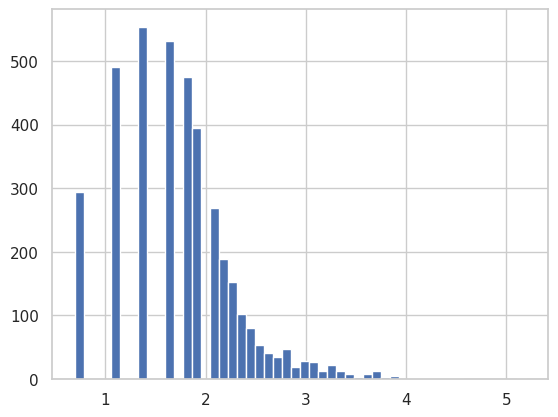

In [14]:
X["mutation_count"].hist(bins=50)

In [15]:
X["msi_score"] = StandardScaler().fit_transform(X[["msi_score"]])

In [16]:
X_train, X_test, T_train, T_test, E_train, E_test = train_test_split(
    X, T, E,
    test_size=0.3,
    random_state=42
)

##  SOLUTION Exercice 1 - Courbe globale

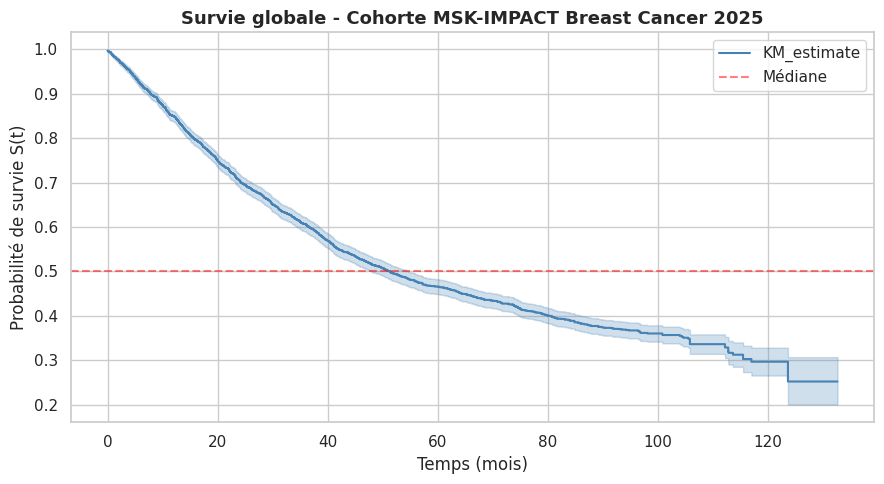

Survie médiane : 51.3 mois


In [48]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E)

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True, color='steelblue')
ax.set_title('Survie globale - Cohorte MSK-IMPACT Breast Cancer 2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Temps (mois)')
ax.set_ylabel('Probabilité de survie S(t)')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Médiane')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Survie médiane : {kmf.median_survival_time_:.1f} mois")

L’estimation de Kaplan-Meier met en évidence une décroissance progressive de la probabilité de survie au sein de la cohorte MSK-IMPACT Breast Cancer 2025. La médiane de survie globale est estimée à 51,3 mois, ce qui signifie que 50 % des patientes présentent un événement (décès) avant cette durée, tandis que l’autre moitié survit au-delà.

La courbe présente une diminution plus marquée durant les premiers mois de suivi, suggérant la présence d’un sous-groupe de patientes à haut risque avec une mortalité précoce potentiellement associée à des formes plus agressives ou métastatiques de la maladie. Après cette phase initiale, la décroissance devient plus progressive, traduisant une hétérogénéité clinique et biologique importante au sein de la cohorte.

L’élargissement des intervalles de confiance en fin de suivi reflète la diminution du nombre de patientes encore à risque, phénomène classique dans les analyses de survie de longue durée. Malgré cela, la courbe conserve une tendance cohérente et biologiquement plausible pour une population oncologique comportant à la fois des tumeurs localisées et avancées.

Ces résultats confirment l’intérêt d’utiliser des modèles de survie capables de prendre en compte :

- la censure des données,
- l’hétérogénéité des profils tumoraux,
- ainsi que les relations potentiellement non linéaires entre variables cliniques et génomiques.

Dans la suite de l’étude, des analyses stratifiées (par statut métastatique, instabilité génomique ou biomarqueurs moléculaires) ainsi que des modèles multivariés de type Cox Proportional Hazards et Random Survival Forest seront utilisés afin d’identifier les facteurs associés au pronostic des patientes.

## SOLUTION Exercice 2 - Primaire vs. Métastatique

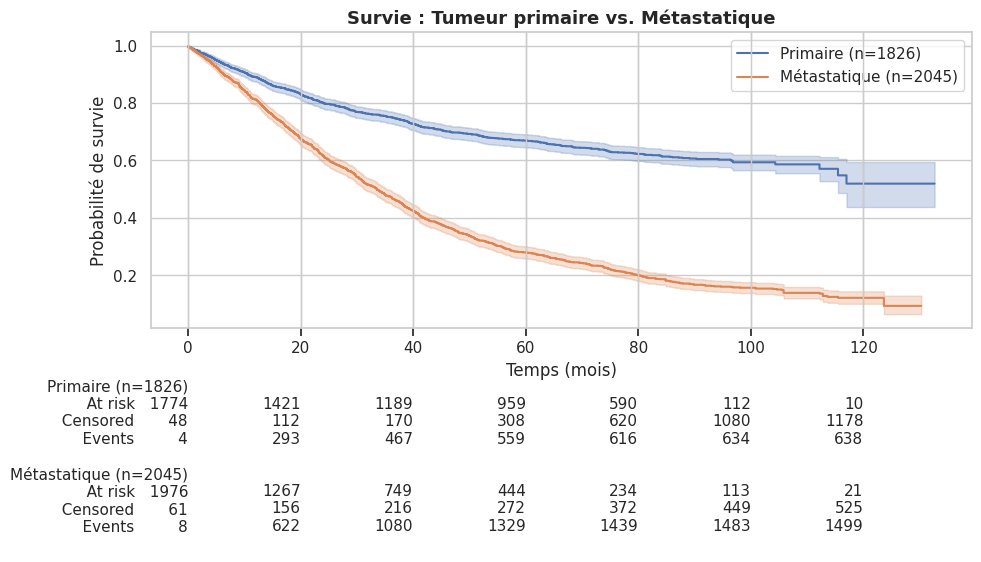

p-value Log-Rank : 0.000000
Test statistique : 613.62
→ Différence statistiquement significative (α=0.05)

Survie médiane — Primaire : inf mois
Survie médiane — Méta    : 33.5 mois


In [17]:
mask_primary = df['is_metastatic'] == 0
mask_meta    = df['is_metastatic'] == 1

kmf_primary = KaplanMeierFitter(label=f'Primaire (n={mask_primary.sum()})')
kmf_primary.fit(T[mask_primary], E[mask_primary])

kmf_meta = KaplanMeierFitter(label=f'Métastatique (n={mask_meta.sum()})')
kmf_meta.fit(T[mask_meta], E[mask_meta])

fig, ax = plt.subplots(figsize=(10, 6))
kmf_primary.plot_survival_function(ax=ax, ci_show=True)
kmf_meta.plot_survival_function(ax=ax, ci_show=True)
ax.set_title('Survie : Tumeur primaire vs. Métastatique', fontsize=13, fontweight='bold')
ax.set_xlabel('Temps (mois)')
ax.set_ylabel('Probabilité de survie')
add_at_risk_counts(kmf_primary, kmf_meta, ax=ax)
plt.tight_layout()
plt.show()

# Test Log-Rank
results = logrank_test(
    T[mask_primary], T[mask_meta],
    event_observed_A=E[mask_primary],
    event_observed_B=E[mask_meta]
)
print(f"p-value Log-Rank : {results.p_value:.6f}")
print(f"Test statistique : {results.test_statistic:.2f}")

if results.p_value < 0.05:
    print('→ Différence statistiquement significative (α=0.05)')
else:
    print('→ Différence NON significative')

print(f"\nSurvie médiane — Primaire : {kmf_primary.median_survival_time_:.1f} mois")
print(f"Survie médiane — Méta    : {kmf_meta.median_survival_time_:.1f} mois")

Analyse - Survie : Tumeur primaire vs. Métastatique
La séparation des courbes est immédiate et s'accentue continuellement sur toute la durée du suivi. Dès les 20 premiers mois, les patientes métastatiques ont déjà perdu environ 40% de survie relative par rapport aux primaires. Cette divergence précoce est un signal fort : le statut métastatique n'est pas seulement un marqueur de sévérité tardive, c'est un facteur pronostique qui agit dès le diagnostic.

Le test du Log-Rank confirme cette observation avec une statistique de 613.62 et une p-value inférieure à 0.000001. La différence est non seulement statistiquement significative mais cliniquement massive. Il faut cependant noter que le Log-Rank ne quantifie pas l'amplitude de la différence, c'est précisément le rôle du Hazard Ratio du modèle de Cox, que nous calculerons en Phase 3.

La survie médiane des métastatiques est de 33.5 mois, soit environ 2 ans et 9 mois après le diagnostic ou l'inclusion. À titre de comparaison, la survie médiane des primaires est indéfinie : plus de 50% de ces patientes sont encore vivantes à 130 mois de suivi, ce qui témoigne d'un pronostic fondamentalement différent sur le long terme.

Le tableau "at risk" révèle un élément important : après 100 mois, il ne reste que 112 patientes primaires et 113 métastatiques à risque. Les intervalles de confiance qui s'élargissent fortement en fin de courbe reflètent directement cette raréfaction de l'information, les estimations après 110 mois doivent être interprétées avec prudence.

Conclusion
Le statut métastatique est le facteur pronostique le plus puissant observable dans ce graphique. Il structure la cohorte en deux populations aux trajectoires radicalement différentes : une population primaire avec une survie prolongée et encore majoritairement vivante à 10 ans, et une population métastatique avec une médiane inférieure à 3 ans. Cette analyse univariée justifie pleinement d'inclure is_metastatic comme covariable prioritaire dans le modèle de Cox multivarié.

## SOLUTION Exercice 3 : FGA High vs Low

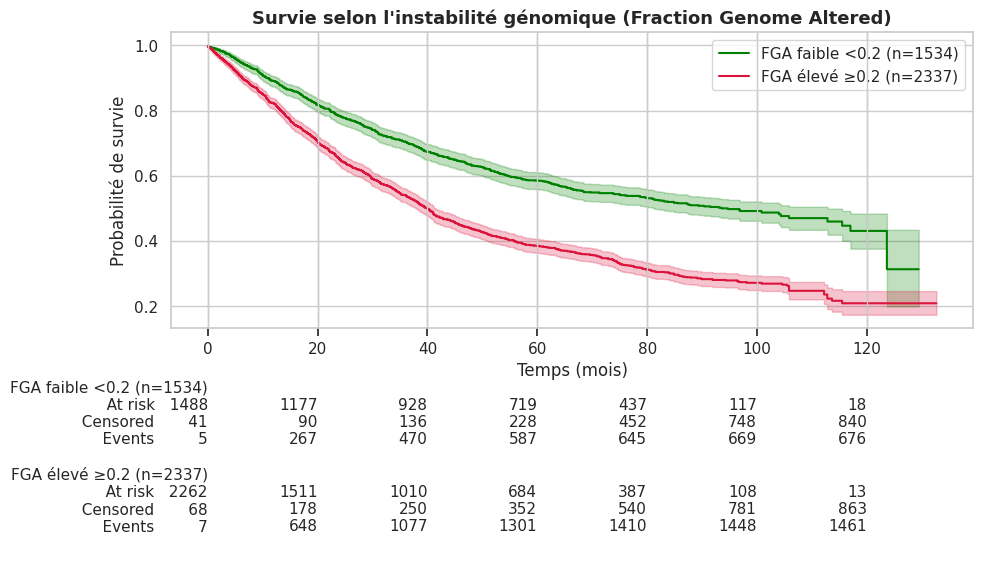

p-value Log-Rank (FGA) : 0.000000


In [21]:
df_fga = df.dropna(subset=['fga_high'])

mask_low  = df_fga['fga_high'] == 0
mask_high = df_fga['fga_high'] == 1

T_fga = df_fga['overall_survival_(months)']
E_fga = df_fga['event']

kmf_low  = KaplanMeierFitter(label=f'FGA faible <0.2 (n={mask_low.sum()})')
kmf_low.fit(T_fga[mask_low], E_fga[mask_low])

kmf_high = KaplanMeierFitter(label=f'FGA élevé ≥0.2 (n={mask_high.sum()})')
kmf_high.fit(T_fga[mask_high], E_fga[mask_high])

fig, ax = plt.subplots(figsize=(10, 6))
kmf_low.plot_survival_function(ax=ax, ci_show=True, color='green')
kmf_high.plot_survival_function(ax=ax, ci_show=True, color='crimson')
ax.set_title('Survie selon l\'instabilité génomique (Fraction Genome Altered)', fontsize=13, fontweight='bold')
ax.set_xlabel('Temps (mois)')
ax.set_ylabel('Probabilité de survie')
add_at_risk_counts(kmf_low, kmf_high, ax=ax)
plt.tight_layout()
plt.show()

res_fga = logrank_test(
    T_fga[mask_low], T_fga[mask_high],
    event_observed_A=E_fga[mask_low],
    event_observed_B=E_fga[mask_high]
)
print(f"p-value Log-Rank (FGA) : {res_fga.p_value:.6f}")

## 💡 Notes pédagogiques

### Points à souligner en séance
- Le KM est **descriptif** : il montre une association, pas une causalité
- Le Log-Rank compare des distributions sur tout le suivi — pas seulement à un instant
- Si les courbes se croisent, le Log-Rank n'est plus adapté (hypothèse de risques proportionnels)
- La survie médiane est NaN si plus de 50% des patients sont encore vivants à la fin du suivi

### Réponses aux questions de réflexion
1. Le Log-Rank suppose des hazards proportionnels — si les courbes se croisent, le test perd de la puissance
2. L'IC 95% reflète l'incertitude sur S(t), qui augmente avec le temps (moins de patients à risque)
3. On peut utiliser le test de Contal-O'Quigley ou regarder les tertiles/quartiles de la distribution